##### Machine Learning LAB 1: MODEL SELECTION

Course 2025/26: *F. Chiariotti*

The notebook contains a simple learning task over which we will implement **MODEL SELECTION AND VALIDATION**.

Complete all the **required code sections** and **answer all the questions**.

### IMPORTANT for the exam:

The functions you might be required to implement in the exam will have the same signature and parameters as the ones in the labs

## Polynomial Classification on Signal to Noise Ratios

In this notebook we are going to explore the use of polynomial classification with polynomial regression. We are going to use the Numpy **polyfit** function, which performs polynomial regression.

Our use case is a communication problem: we have a set of measurements of the Signal to Noise Ratio (SNR), i.e., the quality of the communication link, in various positions. The SNR depends on two components: firstly, the noise level (which is a random variable that does not depend on position) and the signal attenuation (usually modeled as a polynomial function of the distance).

Our transmitter is in (0,0), and coordinates are in meters. In urban scenarios, the attenuation usually follows a third-degree polynomial, but it might be a fourth- or fifth-degree polynomial in more complex cases. How do we choose between different degrees? We will try with a maximum of **6**

---

## Import all the necessary Python libraries

In [310]:
import numpy as np
import scipy as sp
import pandas as pd
import itertools
from matplotlib import pyplot as plt

---

## Load the data

In this case, x and y are the two coordinates, and the SNR is the thing we are trying to predict

**DO NOT CHANGE THE PRE-WRITTEN CODE UNLESS OTHERWISE SPECIFIED**

In [311]:
df = pd.read_csv('data/snr_measurements.csv',sep=';')
x = df['x'].to_numpy()
y = df['y'].to_numpy()
SNR = df['SNR'].to_numpy()

## Helper functions

These functions will help us evaluate the results

In [312]:
def compute_distance(x, y):
    # TODO: Compute the Euclidean distance from the origin
    distance = np.sqrt(x**2+y**2)
    return distance

def fit(distance, SNR, degree):
    return np.polyfit(distance, SNR, deg=degree)

def predict(distance, poly_coeffs):
    # Predict the SNR from a given model
    SNR = np.polyval(poly_coeffs, distance)
    return SNR

def evaluate(distance, SNR, poly_coeffs):
    # TODO: Compute the error of the polynomial fit on the chosen data
    mse = (predict(distance, poly_coeffs) - SNR)**2
    return np.mean(mse)

def separate_test(distance, SNR, test_points):
    # TODO: Return a training set and a test set (the test_points parameter controls the number of test points).
    # The points should be selected randomly
    indices = np.arange(len(distance))
    np.random.shuffle(indices)
    
    test_indices = indices[:test_points]
    train_indices = indices[test_points:]
    
    x_test = distance[test_indices]
    y_test = SNR[test_indices]
    x_train = distance[train_indices]
    y_train = SNR[train_indices]
    
    return x_train, y_train, x_test, y_test

200
40


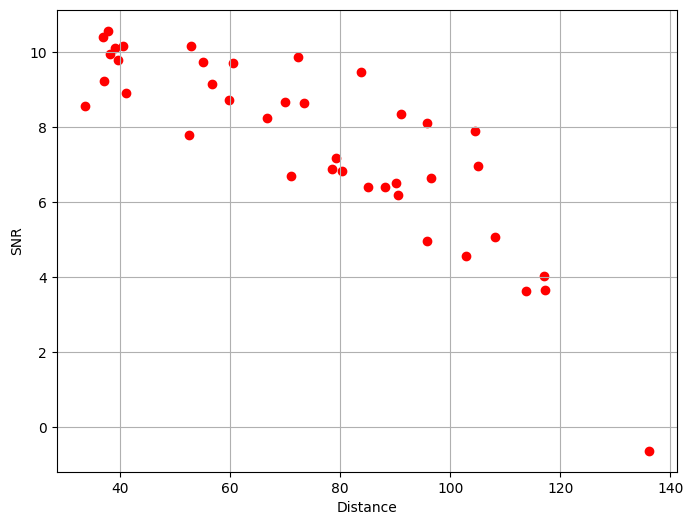

In [313]:
# TODO: separate the training and test sets and create a scatter plot of the SNR as a function of the distance

distance = compute_distance(x,y)
print(len(distance))
distance_train, SNR_train, distance_test, SNR_test = separate_test(distance, SNR, int(np.round(0.2*len(distance))))
print(len(distance_test))

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(distance_test,SNR_test,color='red')
ax.set_xlabel('Distance')
ax.set_ylabel('SNR')
ax.grid()
plt.show()

## A. K-fold cross-validation

In this case, x and y are the two coordinates, and the SNR is the thing we are trying to predict

In [314]:
def k_fold_cross_validation(x_train, y_train, k, max_degree):

    # Shuffle data
    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    x_train = x_train[indices]
    y_train = y_train[indices]

    # Split into k folds
    folds_x = np.array_split(x_train, k)
    folds_y = np.array_split(y_train, k)

    results = []

    for deg in range(1, max_degree + 1):
        fold_scores = []

        for val_fold in range(k):

            # Validation set
            x_val = folds_x[val_fold]
            y_val = folds_y[val_fold]

            # Training set = concatenate all other folds
            x_tr = np.concatenate([folds_x[j] for j in range(k) if j != val_fold])
            y_tr = np.concatenate([folds_y[j] for j in range(k) if j != val_fold])

            coeff = fit(x_tr, y_tr, deg)
            fold_scores.append(evaluate(x_val, y_val, coeff))

        # Store average score for this degree
        results.append(np.mean(fold_scores))

    # Best model = degree with highest mean validation score
    best_degree = np.argmin(results) + 1
    best = fit(x_train, y_train, best_degree)

    return best, results

Validation scores = [np.float64(1.5417860567665191), np.float64(0.9552238093905685), np.float64(0.9328744233134523), np.float64(0.9313745861028037), np.float64(0.9445448504088445), np.float64(0.9303097041488637)]
The best degree is 6
[-9.55425465e-11  4.17162335e-08 -7.21623279e-06  6.25127665e-04
 -2.87653799e-02  6.37143663e-01  4.81526899e+00]


[]

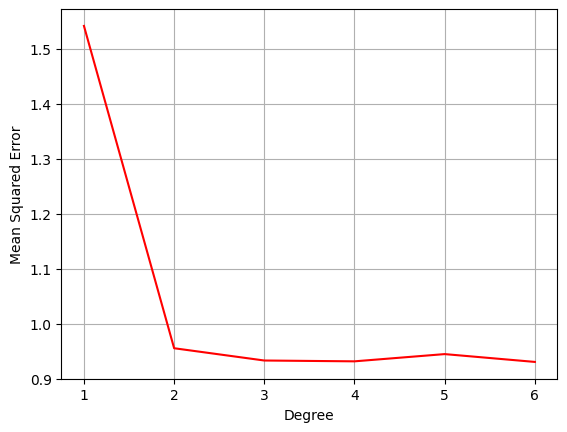

In [315]:
# TODO: run the training with K-fold cross-validation with 40 test points and 4 folds. Plot the validation score as a function of the degree

max_degree = 6
best, results = k_fold_cross_validation(distance_train, SNR_train, k=4, max_degree=max_degree)
print(f'Validation scores = {results}')
print(f'The best degree is {len(best)-1}')
print(best)

plt.plot(np.arange(1,max_degree+1), results, color='red')
plt.xlabel('Degree')
plt.ylabel('Mean Squared Error')
plt.grid()
plt.plot()

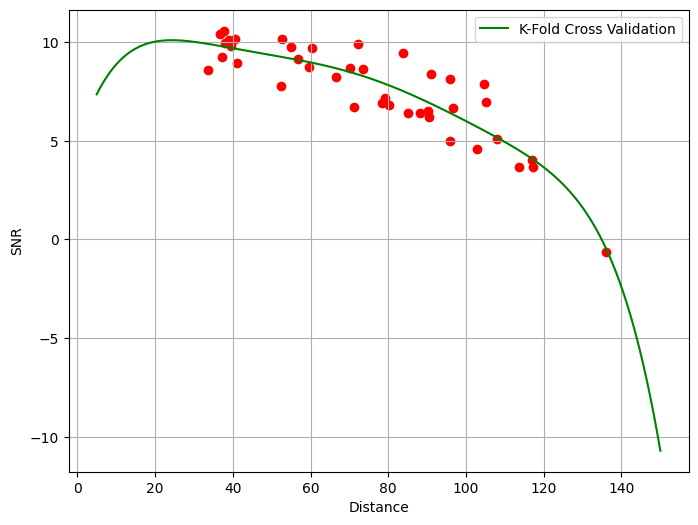

In [316]:
# TODO: get the test performance of the best model and plot the model output and test points. 
# Try running the program multiple times, changing the values of K and the number of test points: is the output always the same?

x_list = np.linspace(5, 150, 1000)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(distance_test,SNR_test,color='red')
ax.plot(x_list, predict(x_list, best), color='green', label='K-Fold Cross Validation')
ax.set_xlabel('Distance')
ax.set_ylabel('SNR')
ax.legend()
ax.grid()
plt.show()

no the output is not the same, firstly because of the shuffled array at the beginning of k-fold cross validation. 

to be statistically meaningful, we should repeat the k-fold n times and then select the degree that has the most outputs

---

## B. Tikhonov regularization

Change the loss function to include a Tikhonov regularization term, as an alternative to cross-validation (try $\lambda=0.01$)

In [317]:
def evaluate_tikhonov(x_train: np.ndarray, y_train: np.ndarray, lambda_par: float, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: apply Tikhonov regularization AFTER the fitting process
    
    results = []
    for degree in range(1, max_degree + 1):
        coeff = fit(x_train, y_train, degree)
        loss = evaluate(np.array(x_train), np.array(y_train), coeff)
        loss += np.sum(coeff*coeff) * lambda_par
        results.append(loss)
    
    best_degree = np.argmin(results) + 1
    best = fit(x_train, y_train, best_degree)
    
    return best, results

Validation scores = [np.float64(3.248221277008726), np.float64(1.7519907339284506), np.float64(2.017484526815079), np.float64(1.6374653294549497), np.float64(2.0165937889433323), np.float64(1.119008622717501)]
The best degree is 6
[-9.55425465e-11  4.17162335e-08 -7.21623279e-06  6.25127665e-04
 -2.87653799e-02  6.37143663e-01  4.81526899e+00]


[]

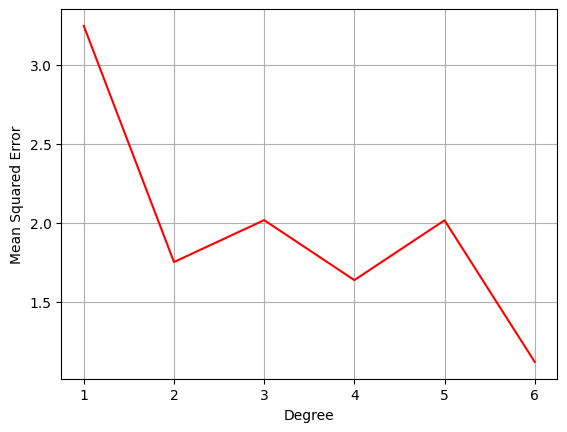

In [318]:
# TODO: run the training with Tikhonov regularization and plot the loss as a function of the degree

max_degree = 6
best, results = evaluate_tikhonov(distance_train, SNR_train, lambda_par=0.01, max_degree=max_degree)
print(f'Validation scores = {results}')
print(f'The best degree is {len(best)-1}')
print(best)

plt.plot(np.arange(1, max_degree+1), results, color='red')
plt.xlabel('Degree')
plt.ylabel('Mean Squared Error')
plt.grid()
plt.plot()

## C. Minimum description length regularization

Change the loss function to include a representation length regularization term, as an alternative to cross-validation. The minimum description length of a polynomial of degree N is O(2^N) - try $\lambda=0.02$

In [319]:
def evaluate_representation(x_train: np.ndarray, y_train: np.ndarray, lambda_par: float, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: apply Tikhonov regularization AFTER the fitting process
    
    results = []
    for degree in range(1, max_degree + 1):
        coeff = fit(x_train, y_train, degree)
        loss = evaluate(np.array(x_train), np.array(y_train), coeff)
        loss += 2**(degree+1) * lambda_par
        results.append(loss)
    
    best_degree = np.argmin(results) + 1
    best = fit(x_train, y_train, best_degree)

    return best, results

Validation scores = [np.float64(1.6189898011735036), np.float64(1.0953600611495553), np.float64(1.2284043541974112), np.float64(1.535164361810775), np.float64(2.1716815817880004), np.float64(3.4430726698385996)]
The best degree is 2
[-8.13553539e-04  5.02688353e-02  9.03662214e+00]


[]

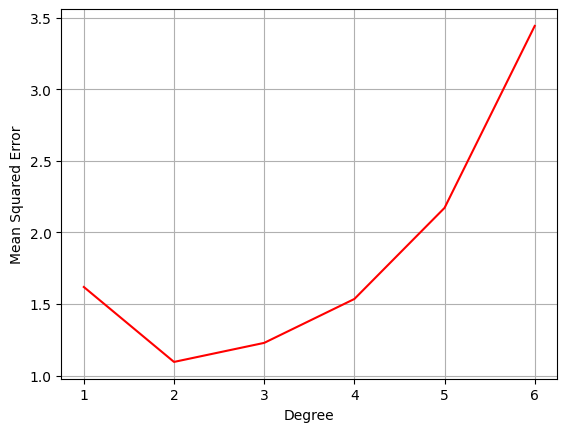

In [320]:
# TODO: run the training with MDL regularization and plot the loss as a function of the degree

max_degree = 6
best, results = evaluate_representation(distance_train, SNR_train, lambda_par=0.02, max_degree=max_degree)
print(f'Validation scores = {results}')
print(f'The best degree is {len(best)-1}')
print(best)

plt.plot(np.arange(1, max_degree+1), results, color='red')
plt.xlabel('Degree')
plt.ylabel('Mean Squared Error')
plt.grid()
plt.plot()

### TEST

Check the performance of the three solutions on the test set: which one does best?


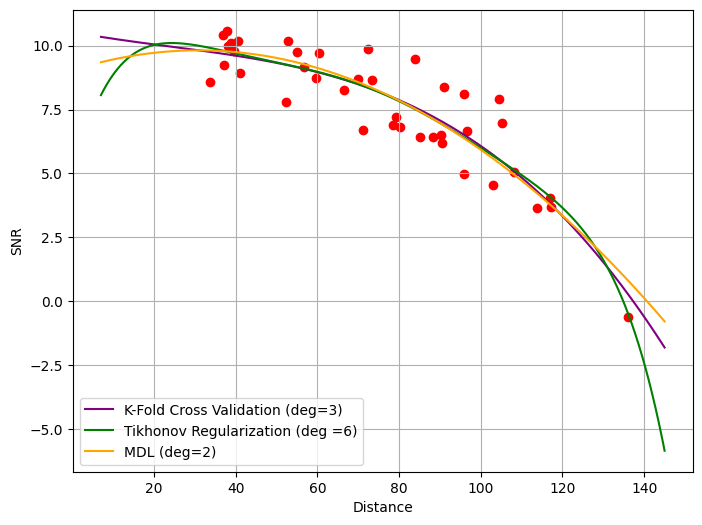

In [321]:
# TODO: plot the results

max_degree = 6

best_kfold = k_fold_cross_validation(distance_train, SNR_train, k=4, max_degree=max_degree)[0]
best_tikh = evaluate_tikhonov(distance_train, SNR_train, lambda_par=0.01, max_degree=max_degree)[0]
best_mdl = evaluate_representation(distance_train, SNR_train, lambda_par=0.02, max_degree=max_degree)[0]

x_list = np.linspace(7, 145, 1000)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(distance_test,SNR_test, color='red')
ax.plot(x_list, predict(x_list, best_kfold), color='purple', label=f'K-Fold Cross Validation (deg={len(best_kfold)-1})')
ax.plot(x_list, predict(x_list, best_tikh), color='green', label=f'Tikhonov Regularization (deg ={len(best_tikh)-1})')
ax.plot(x_list, predict(x_list, best_mdl), color='orange', label=f'MDL (deg={len(best_mdl)-1})')
ax.set_xlabel('Distance')
ax.set_ylabel('SNR')
ax.legend()
ax.grid()
plt.show()